In [1]:
import datetime
import json
from pathlib import Path

import cv2
from tqdm import tqdm
from insightface.app import FaceAnalysis
import onnxruntime as ort

BASE_DIR = Path("/app")
TESTSET_PATH = BASE_DIR / "testsets/four-people_testset.json"
OUTPUT_ROOT = BASE_DIR / "image_outputs"

CLASSIFIER_NAME = "insightface"
DET_SIZE = (640, 640)

print(f"Testset: {TESTSET_PATH}")

/opt/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Testset: /app/testsets/four-people_testset.json


In [2]:
def init_insightface():
    """Initialize InsightFace with both detection AND recognition modules"""
    available = ort.get_available_providers()
    prefer_cuda = "CUDAExecutionProvider" in available
    providers = ["CUDAExecutionProvider", "CPUExecutionProvider"] if prefer_cuda else ["CPUExecutionProvider"]
    ctx_id = 0 if prefer_cuda else -1
    try:
        # Enable both detection and recognition for full face identification
        app = FaceAnalysis(allowed_modules=["detection", "recognition"], providers=providers)
        app.prepare(ctx_id=ctx_id, det_size=DET_SIZE)
        print(f"InsightFace initialized with providers={providers}, ctx_id={ctx_id}")
        print(f"Enabled modules: detection + recognition for face identification")
        return app
    except Exception as e:
        if prefer_cuda:
            print(f"GPU init failed ({e}); retrying on CPU only.")
            providers = ["CPUExecutionProvider"]
            ctx_id = -1
            app = FaceAnalysis(allowed_modules=["detection", "recognition"], providers=providers)
            app.prepare(ctx_id=ctx_id, det_size=DET_SIZE)
            print(f"InsightFace initialized with providers={providers}, ctx_id={ctx_id}")
            return app
        raise

app = init_insightface()

Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}, 'CUDAExecutionProvider': {'sdpa_kernel': '0', 'use_tf32': '1', 'fuse_conv_bias': '0', 'prefer_nhwc': '0', 'tunable_op_max_tuning_duration_ms': '0', 'enable_skip_layer_norm_strict_mode': '0', 'tunable_op_tuning_enable': '0', 'tunable_op_enable': '0', 'use_ep_level_unified_stream': '0', 'device_id': '0', 'has_user_compute_stream': '0', 'gpu_external_empty_cache': '0', 'cudnn_conv_algo_search': 'EXHAUSTIVE', 'cudnn_conv1d_pad_to_nc1d': '0', 'gpu_mem_limit': '18446744073709551615', 'gpu_external_alloc': '0', 'gpu_external_free': '0', 'arena_extend_strategy': 'kNextPowerOfTwo', 'do_copy_in_default_stream': '1', 'enable_cuda_graph': '0', 'user_compute_stream': '0', 'cudnn_conv_use_max_workspace': '1'}}
model ignore: /root/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68
Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CPUExecutionProvid

In [3]:
import numpy as np

# Load reference faces for identification
CELEBRITIES_PATH = BASE_DIR / "data/celebrities.json"
with open(CELEBRITIES_PATH, "r", encoding="utf-8") as f:
    celebrities = json.load(f)

print(f"Loading {len(celebrities)} reference faces for identification...")

# Build reference database with embeddings
reference_db = {}
for celeb in celebrities:
    name = celeb["name"]
    ref_path = BASE_DIR / celeb["reference_image_path"]
    
    if not ref_path.exists():
        print(f"⚠️  Missing reference image for {name}: {ref_path}")
        continue
    
    img = cv2.imread(str(ref_path))
    if img is None:
        print(f"⚠️  Unable to load reference image for {name}")
        continue
    
    faces = app.get(img)
    if not faces:
        print(f"⚠️  No face detected in reference image for {name}")
        continue
    
    # Use the first (or largest) face as reference
    face = max(faces, key=lambda f: (f.bbox[2] - f.bbox[0]) * (f.bbox[3] - f.bbox[1]))
    embedding = face.normed_embedding
    
    reference_db[name] = {
        "embedding": embedding,
        "path": str(ref_path)
    }
    print(f"✓ Loaded reference for {name} (embedding shape: {embedding.shape})")

print(f"\n✓ Reference database ready with {len(reference_db)} identities")

Loading 4 reference faces for identification...


/opt/venv/lib/python3.12/site-packages/insightface/utils/face_align.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `SimilarityTransform.from_estimate` class constructor instead.
  tform.estimate(lmk, dst)


✓ Loaded reference for Hugh Jackman (embedding shape: (512,))
✓ Loaded reference for Donald Trump (embedding shape: (512,))
✓ Loaded reference for Giorgia Meloni (embedding shape: (512,))
✓ Loaded reference for Lionel Messi (embedding shape: (512,))

✓ Reference database ready with 4 identities


In [4]:
with open(TESTSET_PATH, "r", encoding="utf-8") as f:
    test_items = json.load(f)

print(f"Loaded {len(test_items)} images from test set")

Loaded 2503 images from test set


In [5]:
def identify_face(embedding, threshold=0.4):
    """
    Identify a face by comparing its embedding to reference database.
    
    Args:
        embedding: Face embedding from InsightFace
        threshold: Similarity threshold (lower = more strict, default 0.4)
    
    Returns:
        tuple: (name, similarity) or (None, None) if no match
    """
    if not reference_db:
        return None, None
    
    best_match = None
    best_similarity = float('inf')
    
    for name, ref_data in reference_db.items():
        # Compute cosine distance (InsightFace uses normalized embeddings)
        distance = np.linalg.norm(embedding - ref_data["embedding"])
        
        if distance < best_similarity:
            best_similarity = distance
            best_match = name
    
    # Return match if below threshold
    if best_similarity < threshold:
        return best_match, best_similarity
    else:
        return None, None


def get_all_distances(embedding):
    """
    Get distances to ALL reference faces.
    
    Args:
        embedding: Face embedding from InsightFace
    
    Returns:
        dict: {name: distance} sorted by distance (closest first)
    """
    if not reference_db:
        return {}
    
    distances = {}
    for name, ref_data in reference_db.items():
        distance = np.linalg.norm(embedding - ref_data["embedding"])
        distances[name] = distance
    
    # Sort by distance (closest first)
    return dict(sorted(distances.items(), key=lambda x: x[1]))


In [6]:
import csv

timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
output_dir = OUTPUT_ROOT / f"{timestamp}_{CLASSIFIER_NAME}_only-faceDetector_det{DET_SIZE[0]}x{DET_SIZE[1]}"
output_dir.mkdir(parents=True, exist_ok=True)

IDENTIFICATION_THRESHOLD = 1.2  # Adjust as needed (lower = stricter)

# ===== SINGLE EFFICIENT PASS: Process all images once and collect all data =====
# Data structures to collect in single pass
failed = []
stats = {
    "total_images": 0,
    "images_with_faces": 0,
    "total_faces": 0,
    "identified_faces": 0,
    "unknown_faces": 0,
    "by_identity": {}
}

predictions_list = []  # For multilabel metrics
ground_truth_list = []  # For multilabel metrics
all_identity_names = sorted(list(reference_db.keys()))

# Setup CSV writer
csv_path = output_dir / "detailed_distances.csv"
fieldnames = ["image_name", "face_id", "best_match", "best_distance"] + [f"{name}_distance" for name in all_identity_names]
csv_file = open(csv_path, "w", newline="", encoding="utf-8")
csv_writer = csv.DictWriter(csv_file, fieldnames=fieldnames)
csv_writer.writeheader()

face_count_global = 0

print("Processing all images in single pass...")

for item in tqdm(test_items, desc="Processing images"):
    img_path = BASE_DIR / item.get("path", "")
    if not img_path.exists():
        failed.append({"path": str(img_path), "reason": "missing file"})
        continue

    img = cv2.imread(str(img_path))
    if img is None:
        failed.append({"path": str(img_path), "reason": "unable to load"})
        continue

    # ===== SINGLE DETECTION/IDENTIFICATION PASS =====
    faces = app.get(img)
    annotated = img.copy()
    
    stats["total_images"] += 1
    
    # For metrics collection - use "labels" field from test set (not "identities")
    ground_truth = set(item.get("labels", []))
    predicted_identities = set()

    if not faces:
        cv2.putText(annotated, "No faces detected", (10, 25), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 255), 2)
    else:
        stats["images_with_faces"] += 1
        stats["total_faces"] += len(faces)
        
        for face_idx, face in enumerate(faces):
            face_count_global += 1
            
            x1, y1, x2, y2 = [int(v) for v in face.bbox]
            det_score = getattr(face, "det_score", None)
            
            # Get distances to ALL references
            embedding = face.normed_embedding
            all_distances = get_all_distances(embedding)
            
            # Identify the face (best match)
            name, similarity = identify_face(embedding, threshold=IDENTIFICATION_THRESHOLD)
            
            # Update predictions for metrics
            if name:
                predicted_identities.add(name)
                stats["identified_faces"] += 1
                if name not in stats["by_identity"]:
                    stats["by_identity"][name] = {"count": 0, "avg_distance": []}
                stats["by_identity"][name]["count"] += 1
                stats["by_identity"][name]["avg_distance"].append(similarity)
            else:
                stats["unknown_faces"] += 1
            
            # Build multi-line label for visualization
            lines = []
            if name:
                lines.append(f"{name} ✓ (d={similarity:.3f})")
                color = (0, 255, 0)  # Green for identified
            else:
                lines.append("Unknown")
                color = (0, 165, 255)  # Orange for unknown
            
            # Add detection confidence
            if det_score is not None:
                lines.append(f"det={det_score:.2f}")
            
            # Add all distances in order
            lines.append("Distances:")
            for ref_name, dist in list(all_distances.items())[:4]:  # Show top 4
                marker = "→" if ref_name == name else " "
                lines.append(f"  {marker} {ref_name}: {dist:.3f}")
            
            cv2.rectangle(annotated, (x1, y1), (x2, y2), color, 2)
            
            # Draw multi-line label
            y_offset = max(y1 - 10, 10)
            for line in lines:
                cv2.putText(annotated, line, (x1, y_offset), 
                           cv2.FONT_HERSHEY_SIMPLEX, 0.4, color, 1)
                y_offset += 16
            
            # Write CSV row
            csv_row = {
                "image_name": img_path.name,
                "face_id": face_count_global,
                "best_match": name or "Unknown",
                "best_distance": similarity if similarity else "N/A"
            }
            for ref_name, dist in all_distances.items():
                csv_row[f"{ref_name}_distance"] = f"{dist:.4f}"
            csv_writer.writerow(csv_row)

    # Save annotated image
    out_path = output_dir / img_path.name
    cv2.imwrite(str(out_path), annotated)
    
    # Collect for multilabel metrics
    if ground_truth or predicted_identities:
        predictions_list.append(list(predicted_identities))
        ground_truth_list.append(list(ground_truth))

csv_file.close()

# Compute averages for stats
for name in stats["by_identity"]:
    distances = stats["by_identity"][name]["avg_distance"]
    stats["by_identity"][name]["avg_distance"] = np.mean(distances)

print(f"\n✓ Single pass processing complete!")
print(f"✓ Annotated images saved to {output_dir}")
print(f"✓ CSV report saved to {csv_path}")

if failed:
    print(f"⚠️  Skipped {len(failed)} images:")
    for miss in failed[:10]:
        print(f"  - {miss}")
    if len(failed) > 10:
        print(f"  ... and {len(failed) - 10} more")

print(f"✓ Collected {len(predictions_list)} images for metrics evaluation")

# Print identification statistics
print("\n" + "=" * 60)
print("IDENTIFICATION STATISTICS")
print("=" * 60)
print(f"Total images processed: {stats['total_images']}")
print(f"Images with faces: {stats['images_with_faces']}")
print(f"Total faces detected: {stats['total_faces']}")
print(f"Identified faces: {stats['identified_faces']} ({stats['identified_faces']/max(stats['total_faces'],1)*100:.1f}%)")
print(f"Unknown faces: {stats['unknown_faces']} ({stats['unknown_faces']/max(stats['total_faces'],1)*100:.1f}%)")
print()
print("By Identity:")
print("-" * 60)
for name, data in sorted(stats["by_identity"].items(), key=lambda x: x[1]["count"], reverse=True):
    print(f"  {name:20s}: {data['count']:4d} faces (avg distance: {data['avg_distance']:.3f})")
print("=" * 60)


Processing all images in single pass...


Processing images: 100%|██████████| 2503/2503 [03:32<00:00, 11.78it/s]


✓ Single pass processing complete!
✓ Annotated images saved to /app/image_outputs/20260111_132216_insightface_only-faceDetector_det640x640
✓ CSV report saved to /app/image_outputs/20260111_132216_insightface_only-faceDetector_det640x640/detailed_distances.csv
✓ Collected 2503 images for metrics evaluation

IDENTIFICATION STATISTICS
Total images processed: 2503
Images with faces: 2332
Total faces detected: 9949
Identified faces: 1907 (19.2%)
Unknown faces: 8042 (80.8%)

By Identity:
------------------------------------------------------------
  Lionel Messi        :  511 faces (avg distance: 0.948)
  Donald Trump        :  496 faces (avg distance: 0.990)
  Giorgia Meloni      :  474 faces (avg distance: 0.910)
  Hugh Jackman        :  426 faces (avg distance: 0.864)


In [7]:
from sklearn.metrics import (
    precision_score, recall_score, f1_score, accuracy_score,
    confusion_matrix, classification_report, multilabel_confusion_matrix,
    hamming_loss, jaccard_score, roc_auc_score
)
from sklearn.preprocessing import MultiLabelBinarizer
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Data was already collected in previous cell - no re-processing needed
print(f"✓ Using pre-collected data: {len(predictions_list)} images")

# Binarize labels for multilabel metrics
mlb = MultiLabelBinarizer(classes=all_identity_names)
y_true_binary = mlb.fit_transform(ground_truth_list)
y_pred_binary = mlb.transform(predictions_list)

print("\n" + "=" * 70)
print("MULTILABEL MULTICLASS CLASSIFICATION METRICS")
print("=" * 70)

# Subset Accuracy (exact match ratio)
subset_accuracy = accuracy_score(y_true_binary, y_pred_binary)
print(f"\nSubset Accuracy (Exact Match): {subset_accuracy:.4f}")

# Hamming Loss (fraction of labels that are incorrectly predicted)
h_loss = hamming_loss(y_true_binary, y_pred_binary)
print(f"Hamming Loss: {h_loss:.4f}")

# Jaccard Score (intersection / union)
j_score = jaccard_score(y_true_binary, y_pred_binary, average='samples')
print(f"Jaccard Score (samples): {j_score:.4f}")

# Per-label metrics
print("\n" + "-" * 70)
print("Per-Label Metrics (Micro-averaged):")
print("-" * 70)
precision_micro = precision_score(y_true_binary, y_pred_binary, average='micro', zero_division=0)
recall_micro = recall_score(y_true_binary, y_pred_binary, average='micro', zero_division=0)
f1_micro = f1_score(y_true_binary, y_pred_binary, average='micro', zero_division=0)

print(f"Precision (micro): {precision_micro:.4f}")
print(f"Recall (micro):    {recall_micro:.4f}")
print(f"F1-Score (micro):  {f1_micro:.4f}")

# Macro-averaged metrics
print("\n" + "-" * 70)
print("Per-Label Metrics (Macro-averaged):")
print("-" * 70)
precision_macro = precision_score(y_true_binary, y_pred_binary, average='macro', zero_division=0)
recall_macro = recall_score(y_true_binary, y_pred_binary, average='macro', zero_division=0)
f1_macro = f1_score(y_true_binary, y_pred_binary, average='macro', zero_division=0)

print(f"Precision (macro): {precision_macro:.4f}")
print(f"Recall (macro):    {recall_macro:.4f}")
print(f"F1-Score (macro):  {f1_macro:.4f}")

# Weighted-average metrics
print("\n" + "-" * 70)
print("Per-Label Metrics (Weighted-average):")
print("-" * 70)
precision_weighted = precision_score(y_true_binary, y_pred_binary, average='weighted', zero_division=0)
recall_weighted = recall_score(y_true_binary, y_pred_binary, average='weighted', zero_division=0)
f1_weighted = f1_score(y_true_binary, y_pred_binary, average='weighted', zero_division=0)

print(f"Precision (weighted): {precision_weighted:.4f}")
print(f"Recall (weighted):    {recall_weighted:.4f}")
print(f"F1-Score (weighted):  {f1_weighted:.4f}")

# Per-class detailed report
print("\n" + "=" * 70)
print("Per-Class Detailed Report:")
print("=" * 70)
class_report = classification_report(
    y_true_binary, y_pred_binary, 
    target_names=all_identity_names,
    zero_division=0
)
print(class_report)

print("=" * 70)


✓ Using pre-collected data: 2503 images

MULTILABEL MULTICLASS CLASSIFICATION METRICS

Subset Accuracy (Exact Match): 0.8674
Hamming Loss: 0.0333
Jaccard Score (samples): 0.7197

----------------------------------------------------------------------
Per-Label Metrics (Micro-averaged):
----------------------------------------------------------------------
Precision (micro): 0.9952
Recall (micro):    0.8515
F1-Score (micro):  0.9178

----------------------------------------------------------------------
Per-Label Metrics (Macro-averaged):
----------------------------------------------------------------------
Precision (macro): 0.9951
Recall (macro):    0.8525
F1-Score (macro):  0.9181

----------------------------------------------------------------------
Per-Label Metrics (Weighted-average):
----------------------------------------------------------------------
Precision (weighted): 0.9953
Recall (weighted):    0.8515
F1-Score (weighted):  0.9176

Per-Class Detailed Report:
            

/opt/venv/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:1007: UserWarning: unknown class(es) ['None'] will be ignored
  warnings.warn(
/opt/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Jaccard is ill-defined and being set to 0.0 in samples with no true or predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


✓ Metrics visualization saved to: /app/image_outputs/20260111_132216_insightface_only-faceDetector_det640x640/multilabel_multiclass_metrics.png


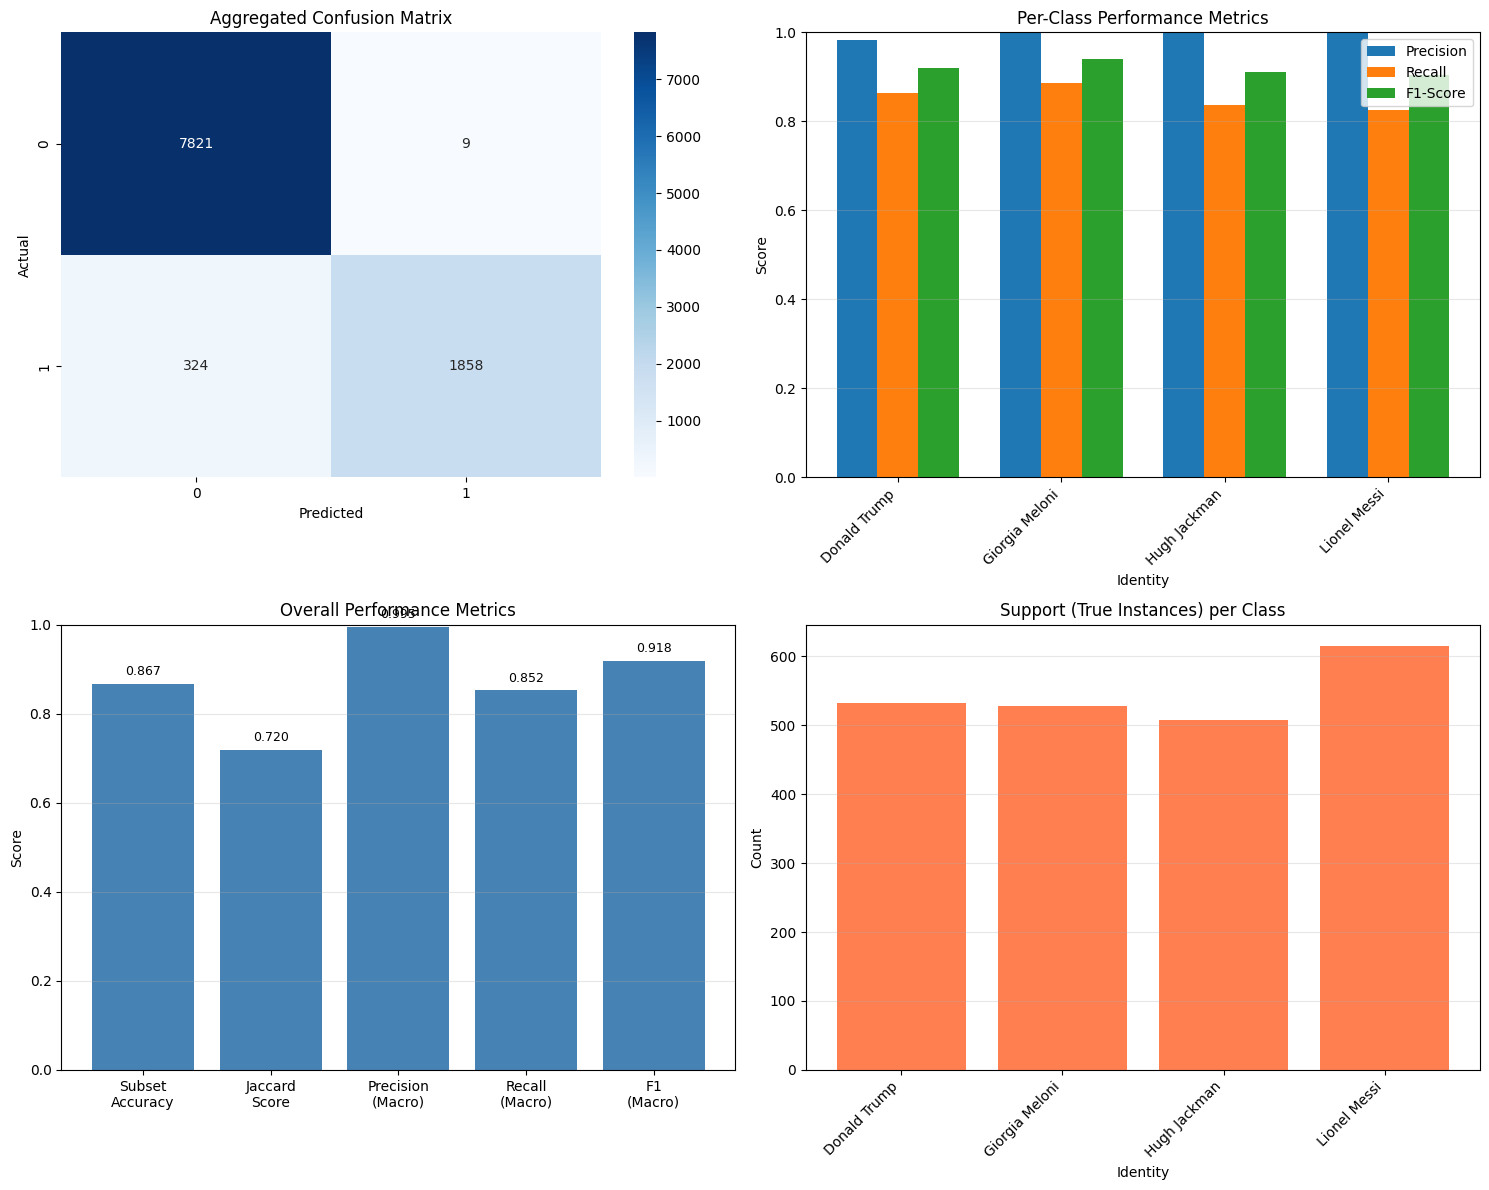

In [8]:
# Visualizations for multilabel multiclass metrics
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Confusion Matrix (aggregated across all labels)
cm = confusion_matrix(y_true_binary.flatten(), y_pred_binary.flatten())
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0])
axes[0, 0].set_title('Aggregated Confusion Matrix')
axes[0, 0].set_xlabel('Predicted')
axes[0, 0].set_ylabel('Actual')

# 2. Per-class metrics comparison
metrics_per_class = []
for i, name in enumerate(all_identity_names):
    prec = precision_score(y_true_binary[:, i], y_pred_binary[:, i], zero_division=0)
    rec = recall_score(y_true_binary[:, i], y_pred_binary[:, i], zero_division=0)
    f1 = f1_score(y_true_binary[:, i], y_pred_binary[:, i], zero_division=0)
    metrics_per_class.append({'name': name, 'precision': prec, 'recall': rec, 'f1': f1})

metrics_df = pd.DataFrame(metrics_per_class)
x_pos = range(len(metrics_df))
width = 0.25

axes[0, 1].bar([p - width for p in x_pos], metrics_df['precision'], width, label='Precision')
axes[0, 1].bar(x_pos, metrics_df['recall'], width, label='Recall')
axes[0, 1].bar([p + width for p in x_pos], metrics_df['f1'], width, label='F1-Score')
axes[0, 1].set_xlabel('Identity')
axes[0, 1].set_ylabel('Score')
axes[0, 1].set_title('Per-Class Performance Metrics')
axes[0, 1].set_xticks(x_pos)
axes[0, 1].set_xticklabels(metrics_df['name'], rotation=45, ha='right')
axes[0, 1].legend()
axes[0, 1].set_ylim([0, 1])
axes[0, 1].grid(axis='y', alpha=0.3)

# 3. Summary metrics comparison
summary_metrics = {
    'Subset\nAccuracy': subset_accuracy,
    'Jaccard\nScore': j_score,
    'Precision\n(Macro)': precision_macro,
    'Recall\n(Macro)': recall_macro,
    'F1\n(Macro)': f1_macro,
}
axes[1, 0].bar(summary_metrics.keys(), summary_metrics.values(), color='steelblue')
axes[1, 0].set_ylabel('Score')
axes[1, 0].set_title('Overall Performance Metrics')
axes[1, 0].set_ylim([0, 1])
axes[1, 0].grid(axis='y', alpha=0.3)
for i, (k, v) in enumerate(summary_metrics.items()):
    axes[1, 0].text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=9)

# 4. Support (number of true instances per class)
support_per_class = y_true_binary.sum(axis=0)
axes[1, 1].bar(all_identity_names, support_per_class, color='coral')
axes[1, 1].set_xlabel('Identity')
axes[1, 1].set_ylabel('Count')
axes[1, 1].set_title('Support (True Instances) per Class')
axes[1, 1].tick_params(axis='x', rotation=45)
plt.setp(axes[1, 1].xaxis.get_majorticklabels(), rotation=45, ha='right')
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
metrics_plot_path = output_dir / "multilabel_multiclass_metrics.png"
plt.savefig(metrics_plot_path, dpi=150, bbox_inches='tight')
print(f"✓ Metrics visualization saved to: {metrics_plot_path}")
plt.show()


In [9]:
# Save detailed metrics to CSV
metrics_summary_path = output_dir / "metrics_summary.csv"
with open(metrics_summary_path, 'w', newline='', encoding='utf-8') as f:
    f.write("Multilabel Multiclass Classification Metrics Summary\n")
    f.write(f"Timestamp: {timestamp}\n")
    f.write(f"Threshold: {IDENTIFICATION_THRESHOLD}\n")
    f.write(f"Images Evaluated: {len(predictions_list)}\n")
    f.write("\n")
    
    f.write("Overall Metrics\n")
    f.write("-" * 50 + "\n")
    f.write(f"Subset Accuracy (Exact Match),{subset_accuracy:.4f}\n")
    f.write(f"Hamming Loss,{h_loss:.4f}\n")
    f.write(f"Jaccard Score,{j_score:.4f}\n")
    f.write("\n")
    
    f.write("Micro-averaged Metrics\n")
    f.write("-" * 50 + "\n")
    f.write(f"Precision,{precision_micro:.4f}\n")
    f.write(f"Recall,{recall_micro:.4f}\n")
    f.write(f"F1-Score,{f1_micro:.4f}\n")
    f.write("\n")
    
    f.write("Macro-averaged Metrics\n")
    f.write("-" * 50 + "\n")
    f.write(f"Precision,{precision_macro:.4f}\n")
    f.write(f"Recall,{recall_macro:.4f}\n")
    f.write(f"F1-Score,{f1_macro:.4f}\n")
    f.write("\n")
    
    f.write("Weighted-average Metrics\n")
    f.write("-" * 50 + "\n")
    f.write(f"Precision,{precision_weighted:.4f}\n")
    f.write(f"Recall,{recall_weighted:.4f}\n")
    f.write(f"F1-Score,{f1_weighted:.4f}\n")
    f.write("\n")
    
    f.write("Per-Class Metrics\n")
    f.write("-" * 50 + "\n")
    f.write("Identity,Precision,Recall,F1-Score,Support\n")
    for i, name in enumerate(all_identity_names):
        prec = precision_score(y_true_binary[:, i], y_pred_binary[:, i], zero_division=0)
        rec = recall_score(y_true_binary[:, i], y_pred_binary[:, i], zero_division=0)
        f1 = f1_score(y_true_binary[:, i], y_pred_binary[:, i], zero_division=0)
        support = int(y_true_binary[:, i].sum())
        f.write(f"{name},{prec:.4f},{rec:.4f},{f1:.4f},{support}\n")

print(f"✓ Metrics summary saved to: {metrics_summary_path}")

# Display summary
print("\n" + "=" * 70)
print("EVALUATION SUMMARY")
print("=" * 70)
print(f"Total images with faces: {len(predictions_list)}")
print(f"Threshold used: {IDENTIFICATION_THRESHOLD}")
print(f"\nBest Metrics:")
print(f"  • Subset Accuracy: {subset_accuracy:.4f} (exact match on all labels)")
print(f"  • F1-Score (Macro): {f1_macro:.4f} (balanced across all classes)")
print(f"  • F1-Score (Weighted): {f1_weighted:.4f} (weighted by support)")
print(f"\nFiles generated:")
print(f"  • {output_dir.name}/multilabel_multiclass_metrics.png")
print(f"  • {output_dir.name}/metrics_summary.csv")
print(f"  • {output_dir.name}/detailed_distances.csv")
print("=" * 70)


✓ Metrics summary saved to: /app/image_outputs/20260111_132216_insightface_only-faceDetector_det640x640/metrics_summary.csv

EVALUATION SUMMARY
Total images with faces: 2503
Threshold used: 1.2

Best Metrics:
  • Subset Accuracy: 0.8674 (exact match on all labels)
  • F1-Score (Macro): 0.9181 (balanced across all classes)
  • F1-Score (Weighted): 0.9176 (weighted by support)

Files generated:
  • 20260111_132216_insightface_only-faceDetector_det640x640/multilabel_multiclass_metrics.png
  • 20260111_132216_insightface_only-faceDetector_det640x640/metrics_summary.csv
  • 20260111_132216_insightface_only-faceDetector_det640x640/detailed_distances.csv


## Identification Statistics

Let's analyze the identification results to see how well the recognition performed.

In [10]:
sample_outputs = sorted(output_dir.iterdir())[:5] if output_dir.exists() else []
print("Sample outputs:")
for p in sample_outputs:
    print(p)

Sample outputs:
/app/image_outputs/20260111_132216_insightface_only-faceDetector_det640x640/001_9adc92c2.jpg
/app/image_outputs/20260111_132216_insightface_only-faceDetector_det640x640/002_85eab275.jpg
/app/image_outputs/20260111_132216_insightface_only-faceDetector_det640x640/003_8889ec2c.jpg
/app/image_outputs/20260111_132216_insightface_only-faceDetector_det640x640/004_41caa173.jpg
/app/image_outputs/20260111_132216_insightface_only-faceDetector_det640x640/005_3ba56da0.jpg
